# Module 8 - Distribution Analysis


## 1. Setup and Data Load

Distribution analysis examines how numerical values are spread across a dataset and helps understand their overall patterns and variability.

This notebook uses the Hotel Booking Demand dataset to analyze important numerical features and their distribution characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("data/hotel_bookings.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### Observation

The dataset is loaded successfully, and the first few records are displayed to understand the available data.

The numerical features will be analyzed for their distribution shape, center, spread, skewness, and presence of outliers.

## 2. Normal Distribution

A normal distribution is a symmetric, bell-shaped distribution where most values are concentrated around the center.

In a normal distribution, the mean and median are usually close to each other.

### Example

A numerical feature with most of its values around the center and fewer values toward both ends may resemble a normal distribution.

### Hotel Booking Dataset

The numerical features in the Hotel Booking Demand dataset can be analyzed to check whether their distributions resemble a normal distribution.

### AI/ML Usage

Normal distribution is important in statistical analysis and is an assumption for some Machine Learning and statistical techniques.

In [2]:
numerical_cols = [
    "lead_time",
    "adr",
    "stays_in_week_nights"
]

for col in numerical_cols:
    data = df[col].dropna()

    print(f"{col}")
    print("Mean:", round(data.mean(), 2))
    print("Median:", round(data.median(), 2))
    print()

lead_time
Mean: 104.01
Median: 69.0

adr
Mean: 101.83
Median: 94.58

stays_in_week_nights
Mean: 2.5
Median: 2.0



### Interpretation

Mean and median values that are close to each other may indicate a more symmetric distribution.

However, mean and median alone are not sufficient to confirm a normal distribution. The shape of the distribution should also be examined using visualizations and statistical tests.

## 3. Uniform Distribution

A uniform distribution is a distribution where values are spread relatively evenly across a given range.

### Example

If observations occur with similar frequency across a range, the feature may show a uniform or approximately uniform distribution.

### Hotel Booking Dataset

The distribution of booking-related numerical features can be examined to determine whether their values are evenly spread across their range.

### AI/ML Usage

Understanding uniform distributions helps identify the shape of numerical features and supports suitable statistical analysis and preprocessing.

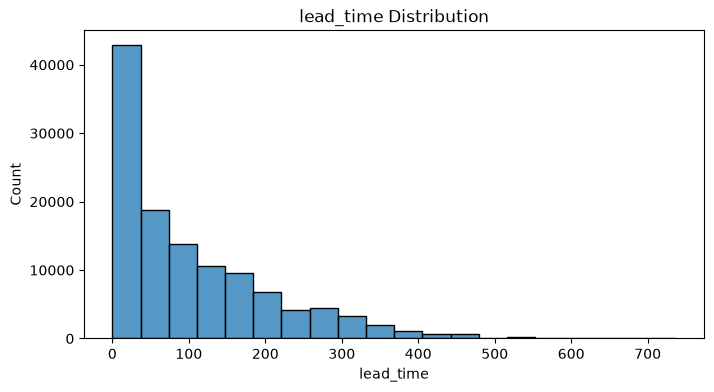

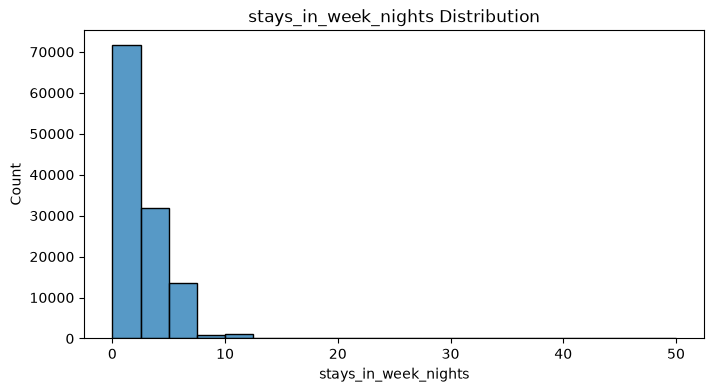

In [3]:
for col in ["lead_time", "stays_in_week_nights"]:
    data = df[col].dropna()

    plt.figure(figsize=(8, 4))
    sns.histplot(data, bins=20)

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

### Interpretation

The histogram shows how the values are distributed across the selected range.

A relatively even spread across the range may indicate a uniform-like distribution, while strong concentration in some areas indicates a different distribution shape.

### Observation

The distribution should be evaluated based on the actual shape of the histogram rather than assuming that a feature is uniform.

### AI/ML Relevance

Identifying the distribution shape helps in selecting appropriate statistical and preprocessing techniques.

## 4. Skewness

Skewness measures the asymmetry of a numerical distribution.

- Skewness close to 0 indicates an approximately symmetric distribution.
- Positive skewness indicates a longer tail on the right.
- Negative skewness indicates a longer tail on the left.

### Implementation

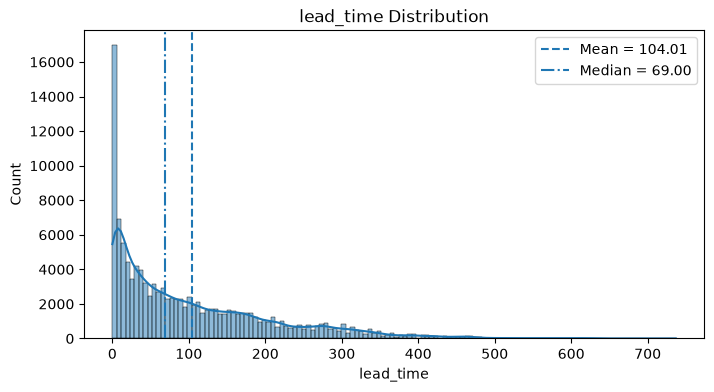

lead_time Skewness: 1.35


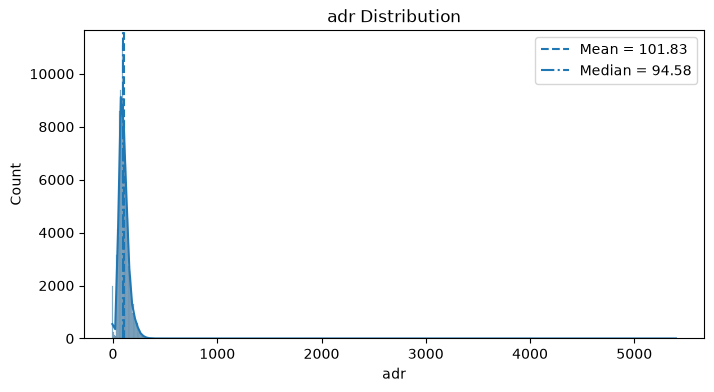

adr Skewness: 10.53


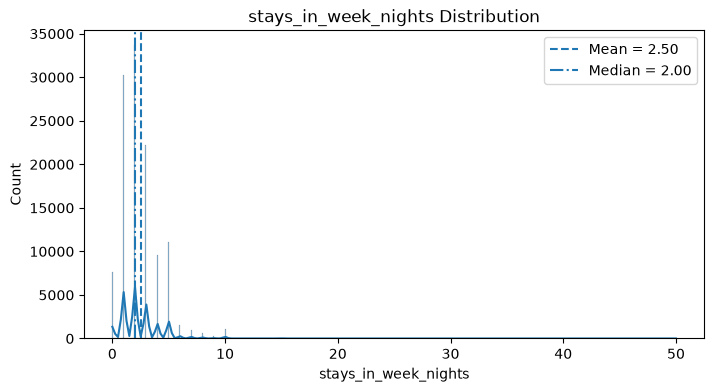

stays_in_week_nights Skewness: 2.86


In [10]:
numerical_cols = ["lead_time", "adr", "stays_in_week_nights"]

for col in numerical_cols:
    data = df[col].dropna()

    plt.figure(figsize=(8, 4))
    sns.histplot(data, kde=True)

    plt.axvline(data.mean(), linestyle="--",
                label=f"Mean = {data.mean():.2f}")
    plt.axvline(data.median(), linestyle="-.",
                label=f"Median = {data.median():.2f}")

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    print(f"{col} Skewness:", round(data.skew(), 2))

### Interpretation

Shape of Distribution: The histogram shows whether the feature is symmetric or skewed.

Center: Mean and median show the central value of the feature.

Spread: The distribution shows how widely the values are spread.

Skewness: The calculated value indicates the direction and degree of asymmetry.

Presence of Outliers: Extreme values visible in the distribution should be examined further.

## 5. Kurtosis

Kurtosis describes the tail behavior of a distribution and helps identify the presence of extreme values.

- Kurtosis close to 0 indicates normal-like tails.
- Positive kurtosis indicates heavier tails.
- Negative kurtosis indicates lighter and flatter tails.

### Implementation

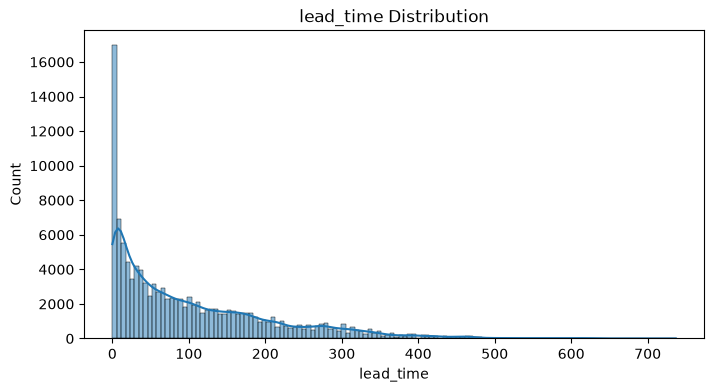

lead_time Kurtosis: 1.7


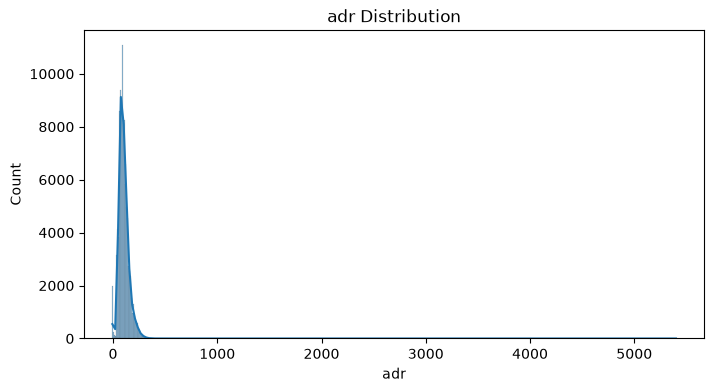

adr Kurtosis: 1013.19


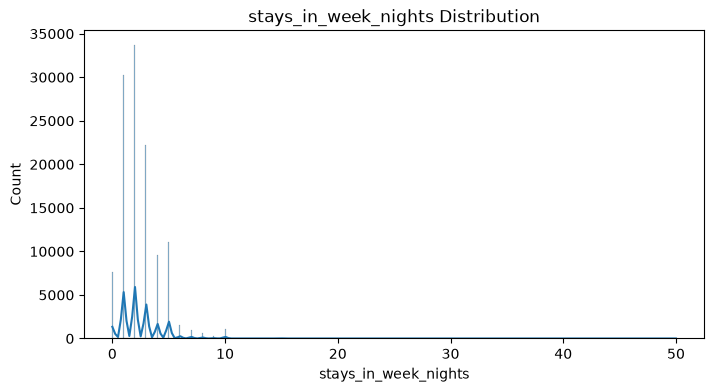

stays_in_week_nights Kurtosis: 24.28


In [11]:
for col in numerical_cols:
    data = df[col].dropna()

    plt.figure(figsize=(8, 4))
    sns.histplot(data, kde=True)

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

    print(f"{col} Kurtosis:", round(data.kurt(), 2))

### Interpretation

Shape of Distribution: The histogram shows the overall shape of the feature.

Center: Mean and median help identify the center of the data.

Spread: The spread shows how much the values vary.

Skewness: Skewness indicates whether the distribution is symmetric or skewed.

Presence of Outliers: Heavy tails may indicate the presence of extreme observations that require further investigation.

## 6. Symmetric Distribution

A symmetric distribution has a similar shape on both sides of its center.

A feature is approximately symmetric when its mean and median are close and its skewness is near zero.

### Implementation

In [12]:
for col in numerical_cols:
    data = df[col].dropna()

    print(
        f"{col} | "
        f"Mean: {data.mean():.2f} | "
        f"Median: {data.median():.2f} | "
        f"Skewness: {data.skew():.2f}"
    )

lead_time | Mean: 104.01 | Median: 69.00 | Skewness: 1.35
adr | Mean: 101.83 | Median: 94.58 | Skewness: 10.53
stays_in_week_nights | Mean: 2.50 | Median: 2.00 | Skewness: 2.86


### Interpretation

Shape of Distribution: A similar spread on both sides indicates a symmetric pattern.

Center: Mean and median are expected to be close.

Spread: Standard deviation and quartiles describe the variation in the feature.

Skewness: A value close to zero indicates approximate symmetry.

Presence of Outliers: Extreme observations should be checked using a box plot.

## 7. Left-Skewed Distribution

A left-skewed distribution has a longer tail toward lower values.

It generally has a negative skewness value, with the mean lower than the median.

### Implementation

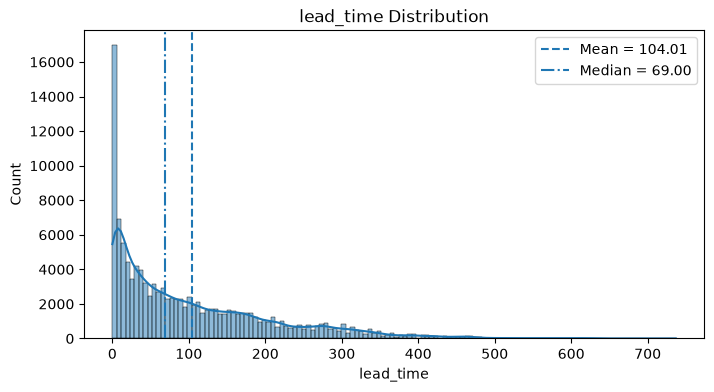

lead_time Skewness: 1.35


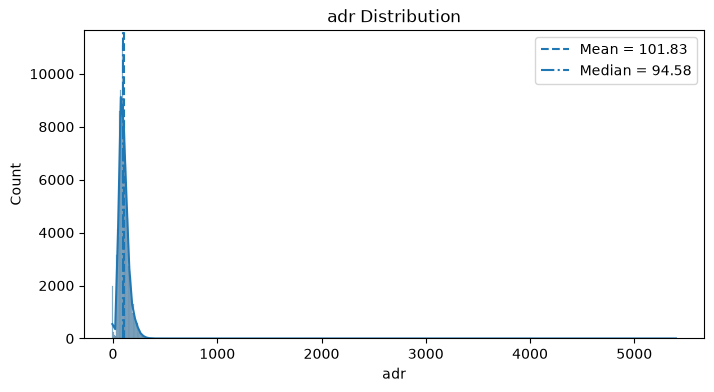

adr Skewness: 10.53


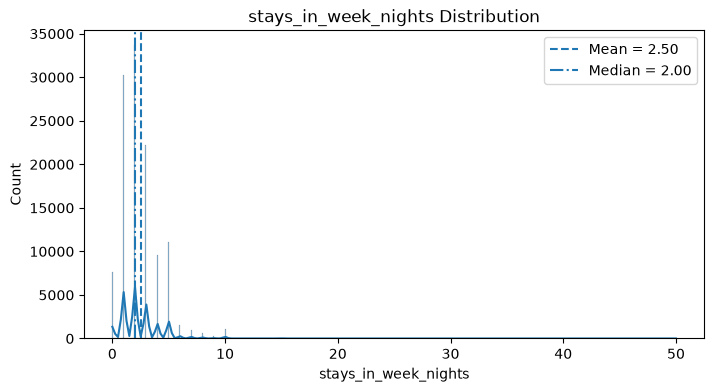

stays_in_week_nights Skewness: 2.86


In [13]:
for col in numerical_cols:
    data = df[col].dropna()

    plt.figure(figsize=(8, 4))
    sns.histplot(data, kde=True)

    plt.axvline(data.mean(), linestyle="--",
                label=f"Mean = {data.mean():.2f}")
    plt.axvline(data.median(), linestyle="-.",
                label=f"Median = {data.median():.2f}")

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    print(f"{col} Skewness:", round(data.skew(), 2))

### Interpretation

Shape of Distribution: A longer tail on the left indicates left skewness.

Center: In a left-skewed distribution, the mean is generally lower than the median.

Spread: The spread shows the variation of values around the center.

Skewness: A negative value indicates left skewness.

Presence of Outliers: Low extreme values should be checked as possible outliers.

## 8. Right-Skewed Distribution

A right-skewed distribution has a longer tail toward higher values.

It generally has a positive skewness value, with the mean higher than the median.

### Implementation

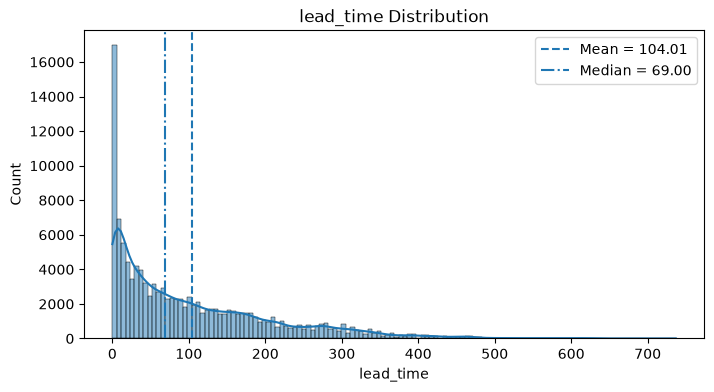

lead_time Skewness: 1.35


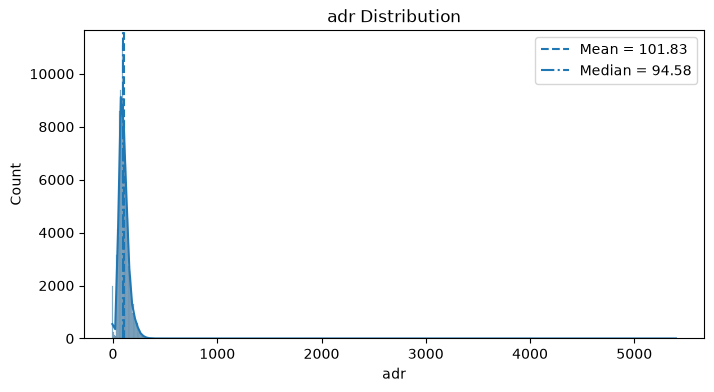

adr Skewness: 10.53


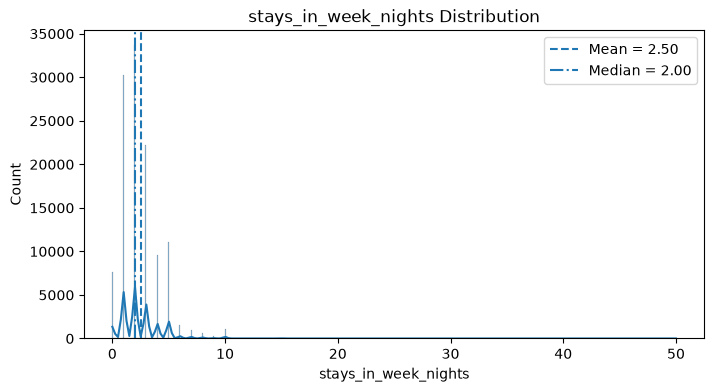

stays_in_week_nights Skewness: 2.86


In [14]:
for col in numerical_cols:
    data = df[col].dropna()

    plt.figure(figsize=(8, 4))
    sns.histplot(data, kde=True)

    plt.axvline(data.mean(), linestyle="--",
                label=f"Mean = {data.mean():.2f}")
    plt.axvline(data.median(), linestyle="-.",
                label=f"Median = {data.median():.2f}")

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.show()

    print(f"{col} Skewness:", round(data.skew(), 2))

### Interpretation

Shape of Distribution: A longer tail on the right indicates right skewness.

Center: In a right-skewed distribution, the mean is generally higher than the median.

Spread: The spread shows the variation of values around the center.

Skewness: A positive value indicates right skewness.

Presence of Outliers: High extreme values should be checked as possible outliers.